## 1. Setup

`PM2.5` adalah target utama, sedangkan `PM10`, `SO2`, `NO2`, `CO`, dan `O3` ikut dimasking karena sensor polutan dapat gagal secara bersamaan. Kolom cuaca (`TEMP`, `PRES`, `DEWP`, `RAIN`, `WSPM`, `wd`) dan metadata lokasi tetap tersedia agar eksperimen berikutnya dapat menguji pemanfaatan informasi temporal dan spasial. Semua baris berasal dari ground truth lengkap, sehingga setiap nilai yang sengaja dihapus memiliki pasangan nilai asli untuk evaluasi.

Setiap severity memakai seed `GLOBAL_SEED + severity_percent * 100`: reproducible, tetapi tidak memaksa mask antar-level menjadi nested atau identik.

In [2]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

GLOBAL_SEED = 42
SEVERITIES = [0.10, 0.20, 0.30, 0.40, 0.50]
MISSING_COLUMNS = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MASK_DIR = PROJECT_ROOT / "data" / "masks"
MASK_DIR.mkdir(parents=True, exist_ok=True)

GROUND_TRUTH_PATH = PROCESSED_DIR / "ground_truth_complete.parquet"
SPLIT_INFO_PATH = PROCESSED_DIR / "train_test_split_info.json"
ground_truth_complete = pd.read_parquet(GROUND_TRUTH_PATH)
with SPLIT_INFO_PATH.open("r", encoding="utf-8") as split_file:
    split_info = json.load(split_file)

ground_truth_complete["datetime"] = pd.to_datetime(ground_truth_complete["datetime"])
ground_truth_complete = ground_truth_complete.reset_index(drop=True)
assert ground_truth_complete[MISSING_COLUMNS].notna().all().all()
assert ground_truth_complete[["station", "datetime"]].duplicated().sum() == 0

print(f"Ground truth: {ground_truth_complete.shape[0]:,} baris x {ground_truth_complete.shape[1]} kolom")
print(f"Seed global: {GLOBAL_SEED}; kolom dimasking: {MISSING_COLUMNS}")
print(f"Train cutoff: {split_info['train_cutoff']}")

Ground truth: 382,168 baris x 21 kolom
Seed global: 42; kolom dimasking: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
Train cutoff: 2016-01-31T23:59:59


Bagaimana sebaiknya missing simulation yang dilakukan, apakah cukup pada data pm2.5 saja, atau lakukan juga sekalian di data polutan lainnya, atau malah ke semua data termasuk data-data meteorologis? pahami alasan ilmiahnya

## 2. Fungsi pembentukan mask

MCAR memilih tepat `round(severity * jumlah posisi)` dari matriks baris-kolom menggunakan `numpy.random.default_rng(seed)`, tanpa melihat nilai data. MAR juga memilih jumlah posisi yang sama, tetapi memberi bobot lebih besar pada observasi dengan `WSPM` rendah atau `RAIN` tinggi sebagai asumsi gangguan sensor saat kondisi cuaca ekstrem. Fungsi mengembalikan DataFrame boolean dengan indeks dan kolom yang sama seperti data yang dimasking; `True` berarti missing.

In [3]:
def _validate_severity(severity):
    if not 0 < severity <= 1:
        raise ValueError("severity harus berada pada interval (0, 1]")


def _mcar_weights(df):
    return np.ones((len(df), len(MISSING_COLUMNS)), dtype=float)


def _mar_weights(df):
    wind = df["WSPM"].to_numpy(dtype=float)
    rain = df["RAIN"].to_numpy(dtype=float)
    wind_rank = pd.Series(wind).rank(pct=True, method="average").to_numpy()
    rain_rank = pd.Series(rain).rank(pct=True, method="average").to_numpy()
    condition_score = 0.5 * (1.0 - wind_rank) + 0.5 * rain_rank
    row_weights = 1.0 + 4.0 * condition_score
    return np.repeat(row_weights[:, None], len(MISSING_COLUMNS), axis=1)


def generate_mask(df, severity, mechanism="MCAR", seed=GLOBAL_SEED):
    """Generate a reproducible exact-count missingness mask."""
    _validate_severity(severity)
    missing_frame = df[MISSING_COLUMNS]
    if missing_frame.isna().any().any():
        raise ValueError("Input harus lengkap pada MISSING_COLUMNS")

    mechanism = mechanism.upper()
    if mechanism == "MCAR":
        weights = _mcar_weights(df)
    elif mechanism == "MAR":
        required_columns = {"WSPM", "RAIN"}
        if not required_columns.issubset(df.columns):
            raise ValueError("MAR membutuhkan kolom WSPM dan RAIN")
        weights = _mar_weights(df)
    else:
        raise ValueError("mechanism harus 'MCAR' atau 'MAR'")

    total_positions = weights.size
    number_to_mask = int(round(severity * total_positions))
    probabilities = weights.ravel() / weights.sum()
    generator = np.random.default_rng(seed)
    selected = generator.choice(total_positions, size=number_to_mask, replace=False, p=probabilities)
    mask_array = np.zeros(total_positions, dtype=bool)
    mask_array[selected] = True
    return pd.DataFrame(
        mask_array.reshape(len(df), len(MISSING_COLUMNS)),
        index=df.index,
        columns=MISSING_COLUMNS,
    )


def apply_mask(df, mask):
    if list(mask.columns) != MISSING_COLUMNS or len(mask) != len(df):
        raise ValueError("Mask tidak cocok dengan dataframe")
    result = df.copy()
    result.loc[:, MISSING_COLUMNS] = result[MISSING_COLUMNS].mask(mask)
    return result


def severity_seed(severity):
    severity_percent = int(round(severity * 100))
    return GLOBAL_SEED + severity_percent * 100

1. Bagaimana bagusnya mekanisme MAR yang dilakukan, apakah mempertimbangkan angin yang tenang dan hujan yang deras saja sudah cukup? atau gua perlu mempertimbangkan kondisi anomali dari faktor meteorologis lain atau bahkan polutan lain? Pahami alasan ilmiahnya
2. saat ini sudah diterapkan mekanisme jika semakin tenang angin dan semakin lebat hujan, maka kemungkinan data hilang (MAR) menjadi lebih besar. Apakah perlu ditambahkan kondisi lain, mungkin seperti kondisi kedua yaitu semakin kencang angin dan semakin lebat hujan juga mampu meningkatkan kemungkinan data hilang, atau cukup satu kondisi aja untuk menyelesaikan penelitian ini?

## 3. Generate dan simpan artefak MCAR

Artefak MCAR menjadi input bersama untuk notebook lanjutan. File `masked_ground_truth` berisi nilai asli hanya pada posisi mask (posisi lain `NaN`), sehingga metrik imputasi dapat dihitung langsung terhadap nilai yang sengaja disembunyikan. Metadata seed dan jumlah posisi turut dicatat dalam tabel ringkasan.

In [4]:
generation_summary = []

for severity in SEVERITIES:
    severity_percent = int(round(severity * 100))
    seed = severity_seed(severity)
    mask = generate_mask(
        ground_truth_complete,
        severity=severity,
        mechanism="MCAR",
        seed=seed,
    )
    df_missing = apply_mask(ground_truth_complete, mask)
    masked_ground_truth = ground_truth_complete[MISSING_COLUMNS].where(mask)

    mask_path = MASK_DIR / f"mask_severity_{severity_percent}.pkl"
    values_path = MASK_DIR / f"masked_ground_truth_severity_{severity_percent}.pkl"
    missing_path = MASK_DIR / f"df_missing_severity_{severity_percent}.parquet"
    with mask_path.open("wb") as mask_file:
        pickle.dump(mask, mask_file, protocol=pickle.HIGHEST_PROTOCOL)
    with values_path.open("wb") as values_file:
        pickle.dump(masked_ground_truth, values_file, protocol=pickle.HIGHEST_PROTOCOL)
    df_missing.to_parquet(missing_path, index=False)

    actual_by_column = df_missing[MISSING_COLUMNS].isna().mean()
    generation_summary.append({
        "severity_target": severity,
        "severity_seed": seed,
        "masked_positions": int(mask.to_numpy().sum()),
        **{f"actual_{column}": actual_by_column[column] for column in MISSING_COLUMNS},
    })

summary_df = pd.DataFrame(generation_summary)
print(summary_df.to_string(index=False))
print(f"Artefak tersimpan di: {MASK_DIR}")

 severity_target  severity_seed  masked_positions  actual_PM2.5  actual_PM10  actual_SO2  actual_NO2  actual_CO  actual_O3
             0.1           1042            229301      0.100479     0.099195    0.100037    0.100218   0.099864   0.100207
             0.2           2042            458602      0.200176     0.200498    0.200121    0.199865   0.200221   0.199119
             0.3           3042            687902      0.300784     0.299986    0.299580    0.301017   0.298256   0.300376
             0.4           4042            917203      0.399727     0.399086    0.400688    0.398738   0.400413   0.401347
             0.5           5042           1146504      0.500523     0.498927    0.500379    0.500298   0.499642   0.500230
Artefak tersimpan di: d:\AI-Research\robust-pm-pred\rb-pm-pred\data\masks


1. MAR masih belum diterapkan ke ground truth? Apakah hanya MCAR saja saat ini yang di-ujicobakan?
2. Apakah perlu data ground truth dibagi juga menjadi train dan test lalu hanya train saja yang diterapkan missing simulation? atau cukup gunakan semua data ground truth saja untuk missing simulation tanpa perlu dibagi menjadi train dan test?

## 4. Verifikasi severity aktual

Karena pemilihan dilakukan atas seluruh posisi matriks secara tepat, persentase aktual per kolom sama dengan target sampai pembulatan integer. Toleransi validasi ditetapkan di bawah 0,5% (0,005 dalam skala proporsi).

In [5]:
verification_rows = []
for severity in SEVERITIES:
    severity_percent = int(round(severity * 100))
    missing_path = MASK_DIR / f"df_missing_severity_{severity_percent}.parquet"
    df_missing = pd.read_parquet(missing_path)
    actual = df_missing[MISSING_COLUMNS].isna().mean()
    for column in MISSING_COLUMNS:
        deviation = abs(float(actual[column]) - severity)
        verification_rows.append({
            "severity_target": severity,
            "column": column,
            "severity_actual": float(actual[column]),
            "deviation": deviation,
            "within_tolerance": deviation < 0.005,
        })

verification_df = pd.DataFrame(verification_rows)
print(verification_df.to_string(index=False))
assert verification_df["within_tolerance"].all()
print("PASS: semua severity aktual memiliki deviasi < 0.5%.")

 severity_target column  severity_actual  deviation  within_tolerance
             0.1  PM2.5         0.100479   0.000479              True
             0.1   PM10         0.099195   0.000805              True
             0.1    SO2         0.100037   0.000037              True
             0.1    NO2         0.100218   0.000218              True
             0.1     CO         0.099864   0.000136              True
             0.1     O3         0.100207   0.000207              True
             0.2  PM2.5         0.200176   0.000176              True
             0.2   PM10         0.200498   0.000498              True
             0.2    SO2         0.200121   0.000121              True
             0.2    NO2         0.199865   0.000135              True
             0.2     CO         0.200221   0.000221              True
             0.2     O3         0.199119   0.000881              True
             0.3  PM2.5         0.300784   0.000784              True
             0.3   P

VALID

## 5. Sanity check distribusi MCAR dan MAR

Pada MCAR, distribusi PM2.5 yang terpilih diharapkan menyerupai distribusi keseluruhan, tanpa pemilihan berbasis nilai. Plot MAR memperlihatkan bahwa baris yang dimasking lebih sering memiliki kombinasi angin rendah dan hujan tinggi sesuai asumsi desain. MAR hanya untuk analisis mekanisme; file input utama tetap MCAR.

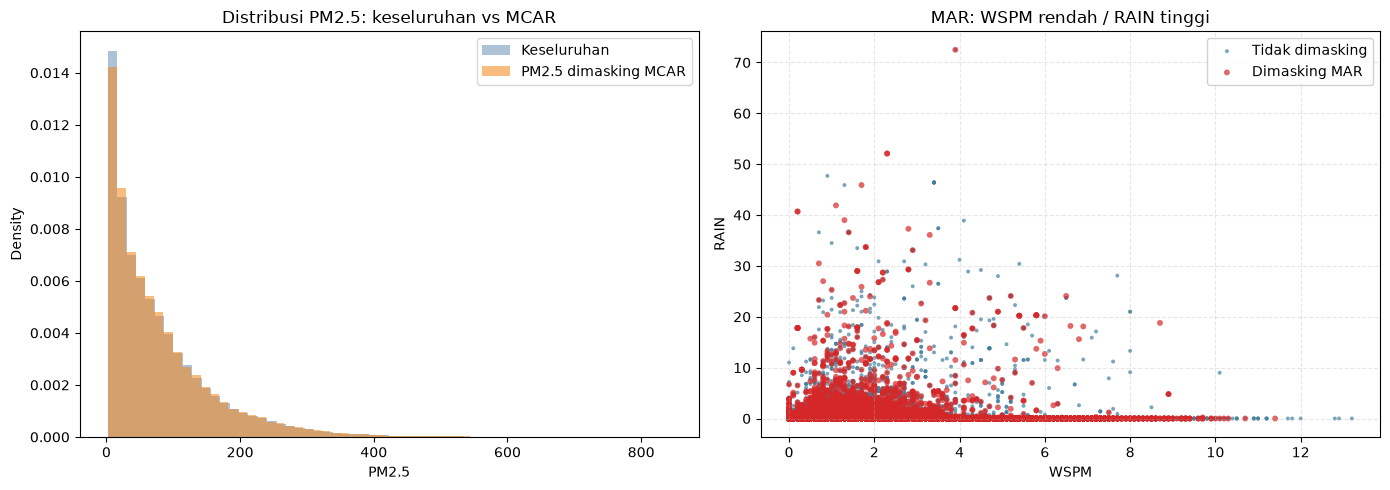

Rata-rata WSPM, tidak dimasking vs MAR: 1.8146479273246363 0.07830352544799113
Rata-rata RAIN, tidak dimasking vs MAR: 0.059346938165402964 0.07830352544799113


In [8]:
plot_severity = 0.30
plot_seed = severity_seed(plot_severity)
plot_mcar_mask = generate_mask(ground_truth_complete, plot_severity, "MCAR", plot_seed)
plot_mar_mask = generate_mask(ground_truth_complete, plot_severity, "MAR", plot_seed)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Tetap Sama (Tidak Mengubah Apa-apa) ---
axes[0].hist(ground_truth_complete["PM2.5"], bins=60, density=True, alpha=0.45, label="Keseluruhan", color="#4c78a8")
axes[0].hist(ground_truth_complete.loc[plot_mcar_mask["PM2.5"], "PM2.5"], bins=60, density=True, alpha=0.55, label="PM2.5 dimasking MCAR", color="#f58518")
axes[0].set_title("Distribusi PM2.5: keseluruhan vs MCAR")
axes[0].set_xlabel("PM2.5")
axes[0].set_ylabel("Density")
axes[0].legend()

# --- Plot 2: Modifikasi Visual MAR ---
# 1. Plot data tidak dimasking di latar belakang dengan opacity lebih rendah & warna netral
axes[1].scatter(
    ground_truth_complete.loc[~plot_mar_mask["PM2.5"], "WSPM"],
    ground_truth_complete.loc[~plot_mar_mask["PM2.5"], "RAIN"],
    s=8,
    alpha=0.70,
    label="Tidak dimasking",
    color="#407f9e",  # Abu-abu netral agar data MAR lebih menonjol
    edgecolors="none"
)

# 2. Plot data dimasking MAR di depan dengan titik lebih besar & warna kontras tinggi
axes[1].scatter(
    ground_truth_complete.loc[plot_mar_mask["PM2.5"], "WSPM"],
    ground_truth_complete.loc[plot_mar_mask["PM2.5"], "RAIN"],
    s=18,
    alpha=0.70,
    label="Dimasking MAR",
    color="#d62728",  # Merah cerah (kontras tinggi)
    edgecolors="none"
)

axes[1].set_title("MAR: WSPM rendah / RAIN tinggi")
axes[1].set_xlabel("WSPM")
axes[1].set_ylabel("RAIN")
axes[1].legend(frameon=True, facecolor="white", framealpha=0.9)
axes[1].grid(True, linestyle="--", alpha=0.3)  # Tambahkan grid tipis untuk keterbacaan posisi data

plt.tight_layout()
plt.show()

print("Rata-rata WSPM, tidak dimasking vs MAR:", ground_truth_complete.loc[~plot_mar_mask["PM2.5"], "WSPM"].mean(), ground_truth_complete.loc[plot_mar_mask["PM2.5"], "RAIN"].mean())
print("Rata-rata RAIN, tidak dimasking vs MAR:", ground_truth_complete.loc[~plot_mar_mask["PM2.5"], "RAIN"].mean(), ground_truth_complete.loc[plot_mar_mask["PM2.5"], "RAIN"].mean())

Sepertinya curah hujan tinggi tidak terlalu mempengaruhi mekanisme MAR, buktinya untuk RAIN > 10, tidak terlihat jumlah titik-titik merah (dimasking MAR) mendominasi daripada titik-titik biru (tidak dimasking), Apakah perlu untuk mempertimbangkan ulang kondisi MAR kalau hasilnya seperti ini? Pahami alasan ilmiahnya

## 6. Validation checklist

Checklist berikut menguji reproducibility dari file yang sudah ditulis ke disk, bukan hanya objek yang masih berada di memori.

In [6]:
def artifact_paths(severity_percent):
    return (
        MASK_DIR / f"mask_severity_{severity_percent}.pkl",
        MASK_DIR / f"masked_ground_truth_severity_{severity_percent}.pkl",
        MASK_DIR / f"df_missing_severity_{severity_percent}.parquet",
    )

all_files_exist = True
all_reload_checks_pass = True
for severity in SEVERITIES:
    severity_percent = int(round(severity * 100))
    mask_path, values_path, missing_path = artifact_paths(severity_percent)
    files_exist = all(path.is_file() for path in (mask_path, values_path, missing_path))
    all_files_exist = all_files_exist and files_exist
    assert files_exist, f"Artefak severity {severity_percent} tidak lengkap"

    with mask_path.open("rb") as mask_file:
        reloaded_mask = pickle.load(mask_file)
    with values_path.open("rb") as values_file:
        reloaded_values = pickle.load(values_file)
    reloaded_missing = pd.read_parquet(missing_path)

    regenerated_missing = apply_mask(ground_truth_complete, reloaded_mask)
    expected_values = ground_truth_complete[MISSING_COLUMNS].where(reloaded_mask)
    pd.testing.assert_frame_equal(reloaded_values, expected_values, check_dtype=False)
    pd.testing.assert_frame_equal(
        reloaded_missing,
        regenerated_missing,
        check_dtype=False,
        check_categorical=False,
    )
    all_reload_checks_pass = all_reload_checks_pass and True

# Temporal split remains valid and every row belongs to exactly one side.
cutoff = pd.Timestamp(split_info["train_cutoff"])
train_rows = ground_truth_complete["datetime"] <= cutoff
test_rows = ground_truth_complete["datetime"] > cutoff
split_is_disjoint = not (train_rows & test_rows).any()
split_is_total = (train_rows | test_rows).all()
datetime_is_valid = ground_truth_complete["datetime"].notna().all()
assert split_is_disjoint and split_is_total and datetime_is_valid

print(f"[{'x' if verification_df['within_tolerance'].all() else ' '}] Severity 10/20/30/40/50 sesuai target, deviasi < 0.5%")
print(f"[{'x' if all_reload_checks_pass else ' '}] Semua mask reload dan re-apply menghasilkan Parquet identik")
print(f"[{'x' if split_is_disjoint and split_is_total and datetime_is_valid else ' '}] Datetime valid; train/test temporal split disjoint dan total")
print(f"[{'x' if all_files_exist else ' '}] Semua mask, masked ground truth, dan Parquet tersedia serta dapat dibuka")
print("Validation checklist selesai: PASS")

[x] Severity 10/20/30/40/50 sesuai target, deviasi < 0.5%
[x] Semua mask reload dan re-apply menghasilkan Parquet identik
[x] Datetime valid; train/test temporal split disjoint dan total
[x] Semua mask, masked ground truth, dan Parquet tersedia serta dapat dibuka
Validation checklist selesai: PASS


VALID